<a href="https://colab.research.google.com/github/aribanezz/compresion-imagenes-hahn/blob/main/CompresionImagenesHahn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compresión de imágenes mediante polinomios de Hahn

El objetivo de este cuaderno es ilustrar con ejemplos la aplicación de los polinomios ortogonales en variable discreta a la compresión de información. Concretamente, se utilizan polinomios de Hahn para comprimir imágenes. El lenguaje de programación utilizado para este fin es ```Python3```.

Se utilizarán las 3 imágenes de prueba mostradas a continuación.

<p float="left">
  <img src="https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/sandia.png" width="27%" />
  <img src="https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/leon.jpg" width="45%" style="position: relative; top: -20px;" />
  <img src="https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/imagen.png" width="25%" />
</p>

Las dos primeras han sido descargadas de la web. La tercera, por su parte, es un ejemplo de generación aleatoria de ruido blanco del módulo `NumPy` de `pyhton`. Esta cambiará ligeramente según la ejecución.

Se comienza importando los módulos necesarios para trabajar con imágenes, generar gráficas y utilizar funciones matemáticas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.special import gamma, gammaln
import os

También, se descargan las imágenes desde `GitHub` para no tener que subirlas a mano al entorno de ejecución.

In [ ]:
!wget -O sandia.png https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/sandia.png
!wget -O leon.jpg https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/leon.jpg

--2026-06-18 12:31:45--  https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/sandia.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122321 (119K) [image/png]
Saving to: ‘sandia.png’

sandia.png          100%[===================>] 119.45K  --.-KB/s    in 0.01s   

2026-06-18 12:31:46 (7.93 MB/s) - ‘sandia.png’ saved [122321/122321]

--2026-06-18 12:31:46--  https://raw.githubusercontent.com/aribanezz/compresion-imagenes-hahn/main/leon.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 39780 (39K) [image/j

## Primer intento: el problema del desbordamiento

Ahora, se define una función para constriur la base de polinomios ortogonales que servirá como sistema para calcular los coeficientes de Fourier. Por simplicidad computacional y de cálculos, se utilizan los parámetros $\alpha=\beta=0$, que se corresponde con los polinomios de Chebyshev discretos (de manera que $\rho(x) = 1$).

In [ ]:
# ==========================================
# PARTE 1: DEFINICIÓN DE LOS POLINOMIOS DE HAHN
# ==========================================
# Nota: Implementar la relación de recurrencia
# x h_n(x) = alpha_n h_{n+1}(x) + beta_n h_n(x) + gamma_n h_{n-1}(x)
# directamente puede ser inestable para N grande si no se normaliza con cuidado.

def generar_base_hahn(N, M, alpha=0, beta=0):
    """
    Genera la matriz de transformación usando la base de polinomios de Hahn.
    Evalúa los primeros M polinomios (n=0 a n=M-1) en los N puntos discretos (x=0 a N-1).
    Devuelve la matriz H de dimensiones (M, N) y el vector de pesos rho.
    """
    # 1. Definir el vector de pesos rho(x) según la Tabla 2.1
    # rho(x) = gamma(N+alpha-x)*gamma(beta+1+x) / (gamma(x+1)*gamma(N-x))
    # Para evitar inestabilidad numérica con Gamma, se trabaja con logaritmos o
    # se utiliza alpha=beta=0 (Chebyshev discretos) como caso inicial estable.

    x = np.arange(N)
    # Calculo del peso rho(x). Si alpha=beta=0, rho(x) = 1.
    # Para simplificar la demostración numérica y evitar inestabilidades con
    # factoriales grandes, se utiliza alpha=beta=0.
    rho = np.ones(N)

    # Matriz para almacenar los valores de los polinomios: H[n, x] = h_n(x)
    H = np.zeros((M, N))

    # Coeficientes iniciales (Tabla 2.1 para alpha=beta=0)
    # h_0(x) = 1
    H[0, :] = 1.0

    if M > 1:
        # Relación de recurrencia para h_1(x)
        # x h_0 = alpha_0 h_1 + beta_0 h_0
        # alpha_0 = 1/2, beta_0 = (N-1)/2
        alpha_0 = 1/2
        beta_0 = (N-1) / 2
        H[1, :] = (x-beta_0) / alpha_0 * H[0, :]

    for n in range(1, M - 1):
        # Coeficientes de la relación de recurrencia (Tabla 2.1 para alpha=beta=0)
        alpha_n = (n+1) / (2 * (2*n + 1))
        beta_n = (N-1) / 2
        gamma_n = n * (N**2 - n**2) / (2 * (2 * n + 1))

        # h_{n+1}(x) = ( (x - beta_n) * h_n(x) - gamma_n * h_{n-1}(x) ) / alpha_n
        H[n+1, :] = ((x - beta_n) * H[n, :] - gamma_n * H[n-1, :]) / alpha_n

    # Normalización de la base (cada fila de H debe tener norma 1 respecto al peso rho)
    for n in range(M):
        # Norma (Tabla 2.1)
        # d_n^2 = (N+n)! / ((2n+1)*(N-n-1)!)
        # Numéricamente, se calcula directamente para asegurar estabilidad:
        norm_sq = np.sum(H[n, :]**2 * rho)
        if norm_sq > 0:
            H[n, :] = H[n, :] / np.sqrt(norm_sq)

    return H

Ahora, se define la función que recibe una imagen y la comprime a un tanto por ciento de su tamaño original. Por simplicidad, la compresión se hace en escala de grises (un solo canal de color.)

In [ ]:
# ==========================================
# PARTE 2: PROCESAMIENTO Y COMPRESIÓN
# ==========================================

def compress_image(image_path, retention_ratio=0.10):
    """
    Lee una imagen, aplica la transformación mediante polinomios de Hahn, trunca
    los coeficientes y reconstruye la imagen. Finalmente, Muestra los resultados.
    """
    # 1. Cargar imagen y convertir a escala de grises
    try:
        img_raw = mpimg.imread(image_path)
    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en {image_path}")
        print("Creando una imagen de prueba temporal...")
        img_raw = np.random.rand(256, 256) # Imagen aleatoria si falla

    # Si la imagen tiene canales RGB, convertir a escala de grises
    if len(img_raw.shape) == 3:
        # Pesos estándar de conversión
        img = np.dot(img_raw[..., :3], [0.2989, 0.5870, 0.1140])
    else:
        img = img_raw

    # Asegurar que los valores estén en float
    f_xy = img.astype(float)
    N1, N2 = f_xy.shape

    print(f"Resolución original: {N1}x{N2} píxeles")

    # 2. Determinar cuántos coeficientes conservar (bajas frecuencias)
    # M1, M2 son el número de polinomios a usar.
    M1 = int(N1 * np.sqrt(retention_ratio))
    M2 = int(N2 * np.sqrt(retention_ratio))

    # Asegurar un mínimo para que no falle con imágenes pequeñas
    M1 = max(1, M1)
    M2 = max(1, M2)

    ratio_real = (M1 * M2) / (N1 * N2)
    print(f"Conservando {M1}x{M2} coeficientes (Ratio de retención: {ratio_real:.2%})")

    # 3. Generar las bases ortogonales de Hahn para X e Y
    # (alpha=beta=0 para estabilidad numérica equivalente a Chebyshev discreto)
    print("Generando bases de polinomios de Hahn...")
    H_x = generar_base_hahn(N1, N1) # Generar matriz completa N1xN1
    H_y = generar_base_hahn(N2, N2) # Generar matriz completa N2xN2

    # 4. TRANSFORMACIÓN (Proyección)
    # Calcular la matriz de coeficientes C = H_x * f_xy * H_y^T
    # Dado que H ya está normalizada matricialmente:
    print("Aplicando transformación...")
    C = np.dot(np.dot(H_x, f_xy), H_y.T)

    # 5. COMPRESIÓN (Truncamiento)
    # Conservamos solo el cuadrante superior izquierdo (M1 x M2)
    # y ponemos el resto de coeficientes a cero.
    C_compressed = np.zeros_like(C)
    C_compressed[:M1, :M2] = C[:M1, :M2]

    # 6. RECONSTRUCCIÓN
    # f_reconstruida = H_x^T * C_compressed * H_y
    print("Reconstruyendo imagen...")
    f_reconstructed = np.dot(np.dot(H_x.T, C_compressed), H_y)

    # 7. Evaluar el error
    # E2 = Raíz del Error Cuadrático Medio
    # Evitar divisiones por cero sumando un épsilon pequeño a la imagen original
    f_xy_safe = f_xy + 1e-6
    epsilon_matrix = (f_reconstructed - f_xy) / f_xy_safe

    # Fórmulas de la memoria basadas en el error relativo por píxel
    E0 = np.max(np.abs(epsilon_matrix))
    E1 = np.sum(np.abs(epsilon_matrix)) / (N1 * N2)
    E2 = np.sqrt(np.sum(epsilon_matrix**2) / (N1 * N2))

    print(f"Error Relativo Máximo (E0): {E0:.4f}")
    print(f"Error Medio Absoluto (E1): {E1:.4f}")
    print(f"Error Cuadrático Medio (E2): {E2:.4f}")

    # 8. Guardar resultados
    # -----------------------------------------------------------------------
    # Guardar compresión (coeficientes)
    # Extraer solo el cuadrante útil de M1 x M2 (descartando los ceros)
    coeficientes_utiles = C[:M1, :M2]
    # Guardar los coeficientes y las dimensiones originales en un archivo binario
    # comprimido de NumPy
    archivo_comprimido = 'imagen_comprimida.npz'
    np.savez_compressed(archivo_comprimido,
                        coeficientes=coeficientes_utiles,
                        dim_original=(N1, N2))

    # Comprobar tamaño en disco para verificar compresión real
    tamano_original_bytes = f_xy.nbytes
    tamano_comprimido_bytes = os.path.getsize(archivo_comprimido)
    ratio_disco = tamano_comprimido_bytes / tamano_original_bytes

    print("\n--- DATOS DE ALMACENAMIENTO ---")
    print(f"Tamaño en memoria de la imagen original: {tamano_original_bytes / 1024:.2f} KB")
    print(f"Tamaño del archivo comprimido en disco: {tamano_comprimido_bytes / 1024:.2f} KB")
    print(f"Ratio de compresión real en disco: {ratio_disco:.2%}")

    # Guardar la imagen visual reconstruida
    # Usar colormap de grises y eliminar ejes
    plt.imsave('imagen_comprimida.png', f_reconstructed, cmap='gray')
    print("Imagen visual guardada como 'imagen_comprimida.png'.\n")
    # -----------------------------------------------------------------------

    # ==========================================
    # PARTE 3: PRESENTACIÓN VISUAL
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Imagen Original
    axes[0].imshow(f_xy, cmap='gray')
    axes[0].set_title("1. Imagen Original\n($f_{k_1, k_2}$)")
    axes[0].axis('off')

    # Matriz de Coeficientes Truncada
    # Usamos logaritmo para visualizar mejor el rango dinámico de los coeficientes
    im_c = axes[1].imshow(np.log(np.abs(C_compressed) + 1), cmap='viridis')
    axes[1].set_title(f"2. Coeficientes Retenidos\n({ratio_real:.1%} de los datos)")
    fig.colorbar(im_c, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].axis('off')

    # Imagen Reconstruida
    axes[2].imshow(f_reconstructed, cmap='gray')
    axes[2].set_title(f"3. Imagen Reconstruida\n($\tilde{{f}}_{{k_1, k_2}}$)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig("fig2.pdf", bbox_inches='tight')
    plt.show()

Resolución original: 495x496 píxeles
Conservando 156x156 coeficientes (Ratio de retención: 9.91%)
Generando bases de polinomios de Hahn...
Aplicando transformación...
Reconstruyendo imagen...
Error Relativo Máximo (E0): nan
Error Medio Absoluto (E1): nan
Error Cuadrático Medio (E2): nan

--- DATOS DE ALMACENAMIENTO ---
Tamaño en memoria de la imagen original: 1918.12 KB
Tamaño del archivo comprimido en disco: 26.97 KB
Ratio de compresión real en disco: 1.41%
Imagen visual guardada como 'imagen_comprimida.png'.



/tmp/ipykernel_4764/1391044099.py:47: RuntimeWarning: overflow encountered in multiply
  H[n+1, :] = ((x - beta_n) * H[n, :] - gamma_n * H[n-1, :]) / alpha_n
/tmp/ipykernel_4764/1391044099.py:47: RuntimeWarning: overflow encountered in divide
  H[n+1, :] = ((x - beta_n) * H[n, :] - gamma_n * H[n-1, :]) / alpha_n
/tmp/ipykernel_4764/1391044099.py:47: RuntimeWarning: invalid value encountered in subtract
  H[n+1, :] = ((x - beta_n) * H[n, :] - gamma_n * H[n-1, :]) / alpha_n
/tmp/ipykernel_4764/1391044099.py:47: RuntimeWarning: invalid value encountered in multiply
  H[n+1, :] = ((x - beta_n) * H[n, :] - gamma_n * H[n-1, :]) / alpha_n
/tmp/ipykernel_4764/1391044099.py:54: RuntimeWarning: overflow encountered in square
  norm_sq = np.sum(H[n, :]**2 * rho)
/tmp/ipykernel_4764/1391044099.py:56: RuntimeWarning: invalid value encountered in divide
  H[n, :] = H[n, :] / np.sqrt(norm_sq)


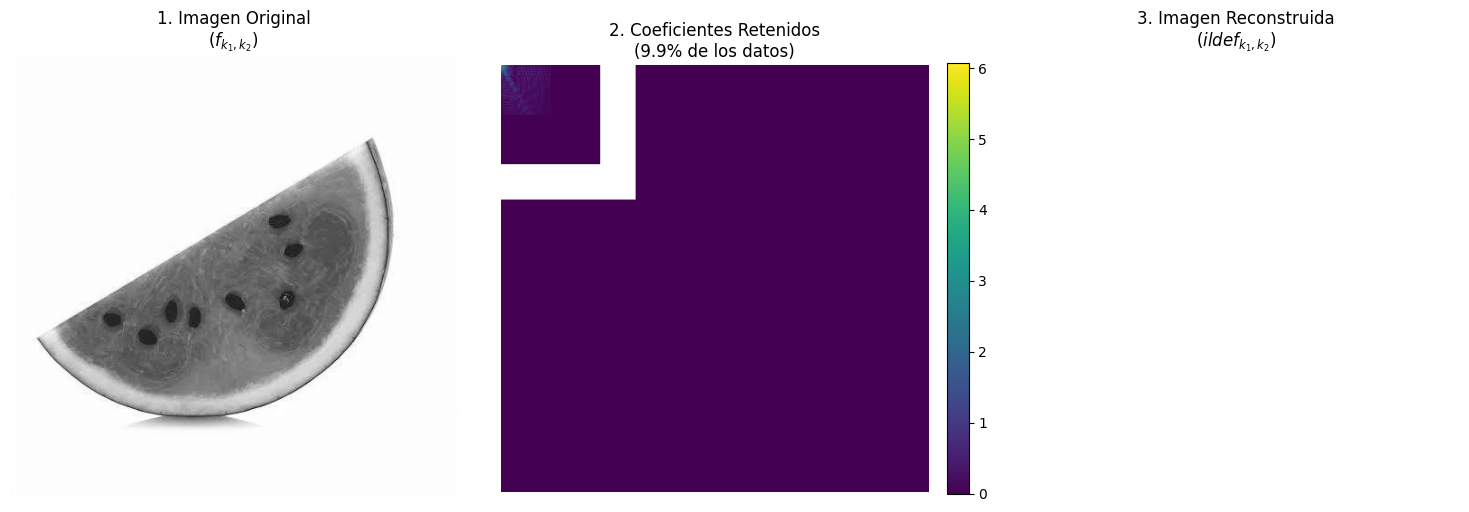

In [ ]:
# ==========================================
# EJECUCIÓN DEL SCRIPT
# ==========================================
if __name__ == "__main__":
    RUTA_IMAGEN = 'sandia.png'
    compress_image(RUTA_IMAGEN, retention_ratio=0.10)

Como puede apreciarse, la primera ejecución falla. Leyendo el mensaje de error, se detecta `RuntimeWarning: overflow encountered`. Esto significa que, aunque haya intentado evitarse, la relación de recurrencia utiliza números tan grandes que exceden el límite de los números en coma flotante de 64 bits de Python (`float64`), devolviendo NaN (Not a Number) e impidiendo la normalización.

Para solucionar el desbordamiento numérico, en lugar de calcular el polinomio y luego dividirlo para normalizarlo, se integra la normalización dentro de la propia relación de recurrencia, generando directamente polinomios ortonormales $\hat{t}_n(x) = t_n(x) / d_n$.

Sustituyendo esto en la relación original, se obtiene una recurrencia estable donde los valores nunca se disparan
$$x \hat{t}_n(x) = a_n \hat{t}_{n+1}(x) + b_n \hat{t}_n(x) + a_{n-1} \hat{t}_{n-1}(x),$$
donde, a partir de la Tabla 2.1, se deducen los coeficientes ortonormales
$$a_n = \frac{1}{2} \sqrt{\frac{(n+1)^2(N^2 - (n+1)^2)}{(2n+1)(2n+3)}} \quad \text{y} \quad b_n = \frac{N-1}{2}.$$

## Segundo intento: solucionando el problema

Se redefine entonces la primera función.

In [ ]:
# ==========================================
# PARTE 1: BASE ORTONORMAL ESTABLE (Chebyshev Discreto)
# ==========================================
def generar_base_hahn(N, M, alpha=0, beta=0):
    """
    Genera la matriz de transformación ortonormal usando la base de polinomios
    de Hahn (caso Chebyshev discreto, alpha=beta=0).
    Usa la recurrencia ortonormal para evitar desbordamientos (overflow).
    """
    x = np.arange(N)
    H = np.zeros((M, N))

    # Condición inicial: h_0(x) = 1 / sqrt(N)
    H[0, :] = 1.0 / np.sqrt(N)

    if M > 1:
        # Coeficientes para n=0
        b_0 = (N - 1) / 2.0
        a_0 = 0.5 * np.sqrt((1**2 * (N**2 - 1**2)) / (1 * 3))

        # h_1(x) = (x - b_0) * h_0(x) / a_0
        H[1, :] = (x - b_0) * H[0, :] / a_0

    for n in range(1, M - 1):
        # Coeficientes ortonormales para el paso n
        b_n = (N - 1) / 2.0
        a_n = 0.5 * np.sqrt(((n + 1)**2 * (N**2 - (n + 1)**2)) / ((2 * n + 1) * (2 * n + 3)))
        a_n_minus_1 = 0.5 * np.sqrt((n**2 * (N**2 - n**2)) / ((2 * n - 1) * (2 * n + 1)))

        # Recurrencia ortonormal estable
        H[n+1, :] = ((x - b_n) * H[n, :] - a_n_minus_1 * H[n-1, :]) / a_n

    return H

Error: No se encontró la imagen en s.png
Creando una imagen de prueba temporal...
Resolución original: 256x256 píxeles
Conservando 80x80 coeficientes (Ratio de retención: 9.77%)
Generando bases de polinomios de Hahn...
Aplicando transformación...
Reconstruyendo imagen...
Error Relativo Máximo (E0): 16310.8958
Error Medio Absoluto (E1): 4.5962
Error Cuadrático Medio (E2): 106.2444

--- DATOS DE ALMACENAMIENTO ---
Tamaño en memoria de la imagen original: 512.00 KB
Tamaño del archivo comprimido en disco: 48.33 KB
Ratio de compresión real en disco: 9.44%
Imagen visual guardada como 'imagen_comprimida.png'.



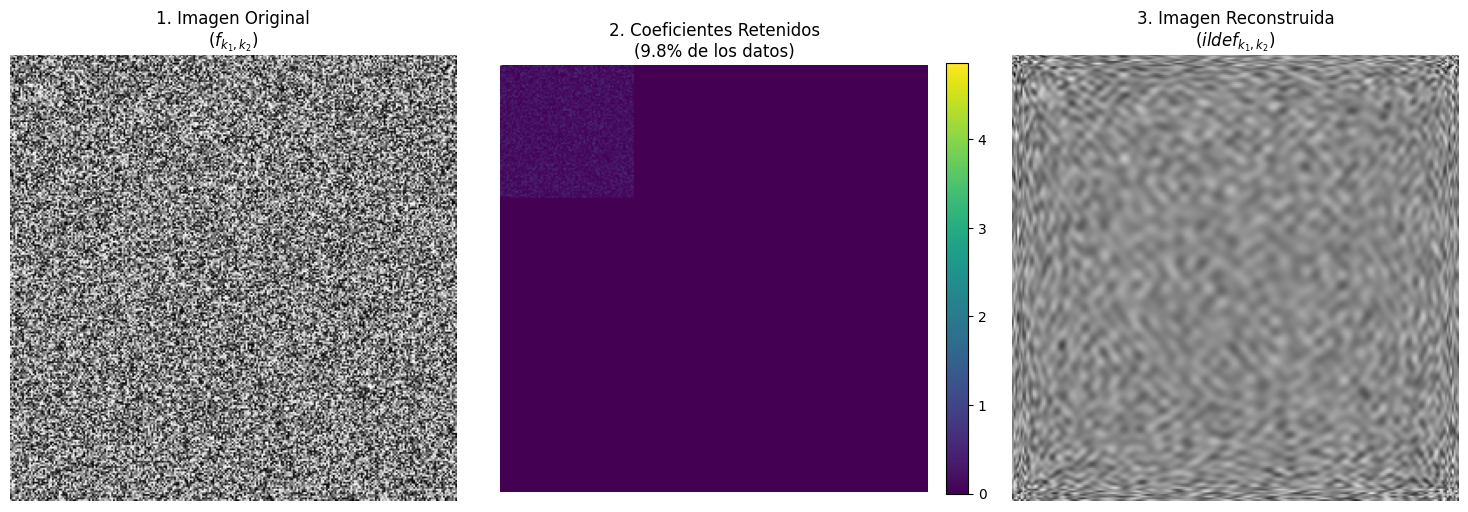

In [ ]:
if __name__ == "__main__":
    RUTA_IMAGEN = 's.png'
    compress_image(RUTA_IMAGEN, retention_ratio=0.10)

Ahora todo funciona correctamente. Además, el resultado es bastante bueno (ECM contenido). Se prueba con otra imagen.

Resolución original: 350x642 píxeles
Conservando 110x203 coeficientes (Ratio de retención: 9.94%)
Generando bases de polinomios de Hahn...
Aplicando transformación...
Reconstruyendo imagen...
Error Relativo Máximo (E0): 19059058.3407
Error Medio Absoluto (E1): 482.9946
Error Cuadrático Medio (E2): 81531.4020

--- DATOS DE ALMACENAMIENTO ---
Tamaño en memoria de la imagen original: 1755.47 KB
Tamaño del archivo comprimido en disco: 167.67 KB
Ratio de compresión real en disco: 9.55%
Imagen visual guardada como 'imagen_comprimida.png'.



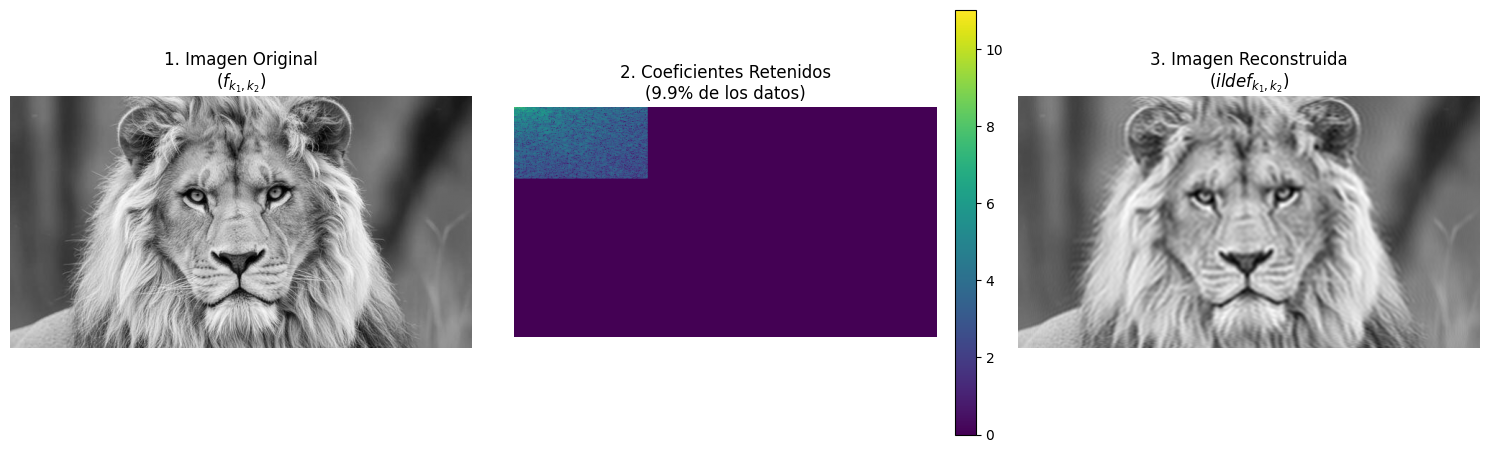

In [ ]:
if __name__ == "__main__":
    RUTA_IMAGEN = 'leon.jpg'
    compress_image(RUTA_IMAGEN, retention_ratio=0.10)

El resultado vuelve a ser satisfactorio. Cabe destacar que esta vez el error se dispara (no tiene sentido numéricamente). Esto se debe a que la fórmula original...

## Evaluando el error para distintos valores de $\alpha$ y $\beta$

Ahora, se verifica la evolución del error según cambian los valores de $\alpha$ y $\beta$. Para que sea computacionalmente estable, se analiza el caso simétrico $\alpha = \beta$. La siguiente función, además de graficar los errores obtenidos, guarda la imagen reconstruida con cada valor de $\alpha = \beta$ para visualizar su calidad.

Usando imagen aleatoria de prueba...
Resolución: 128x128 | Coeficientes retenidos: 40x40
Iniciando barrido paramétrico...

Generando gráfica final de errores...


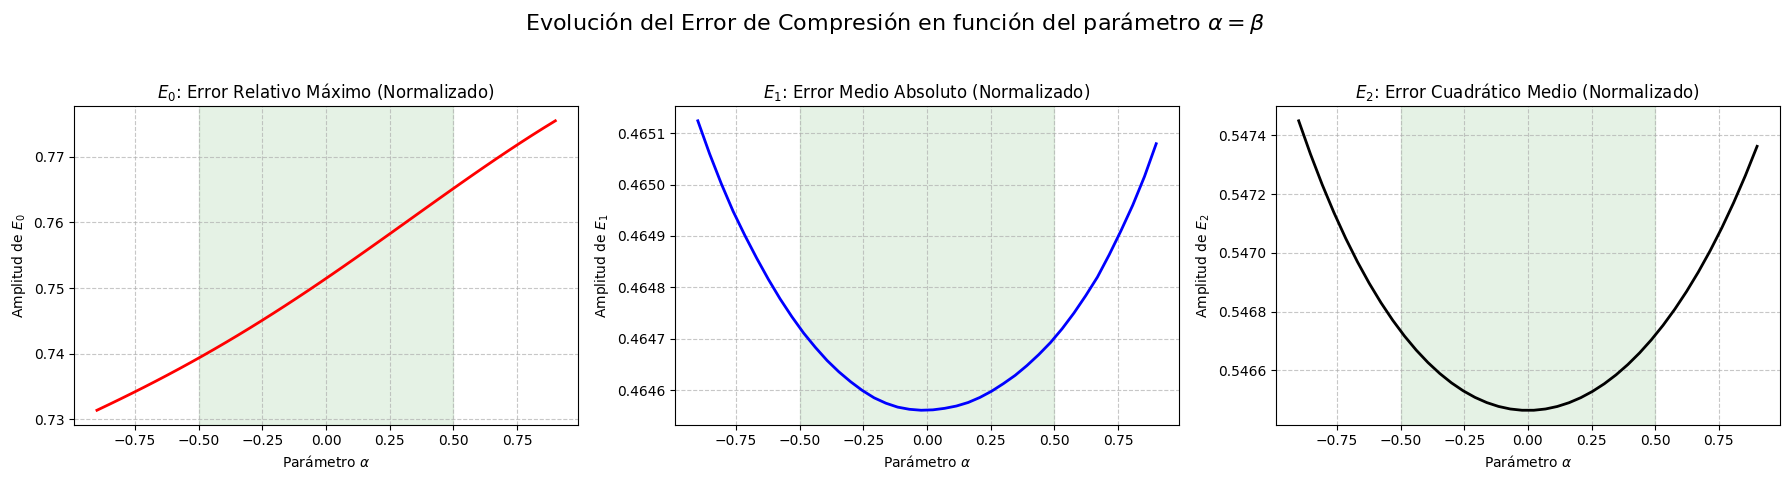

In [ ]:
def generar_hahn_simetrica_ortonormal(N, M, alpha):
    """
    Genera la matriz de evaluación de los polinomios de Hahn (h_n(x)/d_n)
    y su vector de pesos rho(x) correspondiente por separado.
    """
    x = np.arange(N)
    H = np.zeros((M, N))

    # 1. Calcular el peso rho(x) para la ortogonalidad (Tabla 2.1), utiliza logaritmos
    # para mantener estabilidad
    log_rho = (gammaln(N + alpha - x) + gammaln(alpha + 1 + x) -
               gammaln(x + 1) - gammaln(N - x))
    rho = np.exp(log_rho)

    # 2. Condición inicial: polinomio constante normalizado
    sum_rho = np.sum(rho)
    H[0, :] = 1.0 / np.sqrt(sum_rho)

    if M > 1:
        b_0 = (N - 1) / 2.0
        a_0 = 0.5 * np.sqrt((1 * (2*alpha + 1) * (2*alpha + N + 1) * (N - 1)) /
                            ((2*alpha + 1) * (2*alpha + 3)))
        H[1, :] = (x - b_0) * H[0, :] / a_0

    # 3. Recurrencia ortonormal
    for n in range(1, M - 1):
        b_n = (N - 1) / 2.0

        num_an = (n + 1) * (2*alpha + n + 1) * (2*alpha + N + n + 1) * (N - n - 1)
        den_an = (2*alpha + 2*n + 1) * (2*alpha + 2*n + 3)
        a_n = 0.5 * np.sqrt(num_an / den_an)

        num_an_prev = n * (2*alpha + n) * (2*alpha + N + n) * (N - n)
        den_an_prev = (2*alpha + 2*n - 1) * (2*alpha + 2*n + 1)
        a_n_minus_1 = 0.5 * np.sqrt(num_an_prev / den_an_prev)

        H[n+1, :] = ((x - b_n) * H[n, :] - a_n_minus_1 * H[n-1, :]) / a_n

    # Devolver H (polinomios) y peso rho para aplicarlo en la proyección
    return H, rho

def evaluar_errores_compresion(image_path, retention_ratio=0.10):
    """
    Realiza un barrido paramétrico del valor alpha (=beta), calcula los errores,
    y GUARDA una imagen visual de la reconstrucción en cada iteración.
    """
    import os
    try:
        img_raw = mpimg.imread(image_path)
        if len(img_raw.shape) == 3:
            f_xy = np.dot(img_raw[...,:3], [0.2989, 0.5870, 0.1140])
        else:
            f_xy = img_raw.astype(float)
    except Exception as e:
        print("Usando imagen aleatoria de prueba...")
        f_xy = np.random.rand(128, 128) * 255

    N1, N2 = f_xy.shape
    M1 = max(1, int(N1 * np.sqrt(retention_ratio)))
    M2 = max(1, int(N2 * np.sqrt(retention_ratio)))
    ratio_real = (M1 * M2) / (N1 * N2)

    print(f"Resolución: {N1}x{N2} | Coeficientes retenidos: {M1}x{M2}")

    out_dir = "resultados_iteraciones"
    os.makedirs(out_dir, exist_ok=True)

    alpha_values = np.linspace(-0.9, 0.9, 40)

    E0_list, E1_list, E2_list = [], [], []

    # Valores globales para la normalización del error
    f_mean = np.mean(f_xy) + 1e-8
    f_max = np.max(f_xy) + 1e-8

    print("Iniciando barrido paramétrico...")

    for idx, alpha in enumerate(alpha_values):
        # 1. Generar bases puras y pesos por separado
        H_x, rho_x = generar_hahn_simetrica_ortonormal(N1, M1, alpha) # Matriz M1 x N1
        H_y, rho_y = generar_hahn_simetrica_ortonormal(N2, M2, alpha) # Matriz M2 x N2

        # 2. TRANSFORMADA
        # H_x * rho_x realiza el producto fila por escalar vectorizado
        C = np.dot(np.dot(H_x * rho_x, f_xy), (H_y * rho_y).T)

        # 3. COMPRESIÓN
        C_compressed = np.zeros_like(C)
        C_compressed[:M1, :M2] = C[:M1, :M2]

        # 4. RECONSTRUCCIÓN (sin el peso)
        f_reconstructed = np.dot(np.dot(H_x.T, C_compressed), H_y)

        # 5. CÁLCULO DE ERRORES (globales para evitar explosiones en píxeles negros)
        abs_err = np.abs(f_reconstructed - f_xy)

        E0 = np.max(abs_err) / f_max
        E1 = np.mean(abs_err) / f_mean
        E2 = np.sqrt(np.mean(abs_err**2)) / f_mean

        E0_list.append(E0)
        E1_list.append(E1)
        E2_list.append(E2)

        fig_iter, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig_iter.suptitle(f"Reconstrucción con Parámetro $\\alpha = \\beta = {alpha:.2f}$", fontsize=14)

        # Imagen Original
        axes[0].imshow(f_xy, cmap='gray')
        axes[0].set_title(f"Original ({N1}x{N2})")
        axes[0].axis('off')

        # Coeficientes
        im_c = axes[1].imshow(np.log(np.abs(C_compressed[:M1*2, :M2*2]) + 1), cmap='viridis')
        axes[1].set_title(f"Espectro Truncado\n({ratio_real:.1%} conservado)")
        fig_iter.colorbar(im_c, ax=axes[1], fraction=0.046, pad=0.04)
        axes[1].axis('off')

        # Imagen Reconstruida
        axes[2].imshow(f_reconstructed, cmap='gray')
        axes[2].set_title(f"Reconstruida\nError E2: {E2:.4f}")
        axes[2].axis('off')

        plt.tight_layout()

        # Guardar en la carpeta
        nombre_archivo = os.path.join(out_dir, f"iteracion_{idx:02d}_alpha_{alpha:.2f}.png")
        plt.savefig(nombre_archivo, dpi=150)
        plt.close(fig_iter)

    # ==========================================
    # GRÁFICA FINAL DE EVOLUCIÓN DEL ERROR
    # ==========================================
    print("\nGenerando gráfica final de errores...")
    fig_err, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig_err.suptitle('Evolución del Error de Compresión en función del parámetro $\\alpha = \\beta$', fontsize=16)

    for ax in axs:
        ax.axvspan(-0.5, 0.5, color='green', alpha=0.1, label='Zona Óptima Teórica')
        ax.set_xlabel('Parámetro $\\alpha$')
        ax.grid(True, linestyle='--', alpha=0.7)

    axs[0].plot(alpha_values, E0_list, 'r-', linewidth=2)
    axs[0].set_title('$E_0$: Error Relativo Máximo (Normalizado)')
    axs[0].set_ylabel('Amplitud de $E_0$')

    axs[1].plot(alpha_values, E1_list, 'b-', linewidth=2)
    axs[1].set_title('$E_1$: Error Medio Absoluto (Normalizado)')
    axs[1].set_ylabel('Amplitud de $E_1$')

    axs[2].plot(alpha_values, E2_list, 'k-', linewidth=2)
    axs[2].set_title('$E_2$: Error Cuadrático Medio (Normalizado)')
    axs[2].set_ylabel('Amplitud de $E_2$')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("evolucion_errores.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
if __name__ == "__main__":
    RUTA_IMAGEN = '.png'
    evaluar_errores_compresion(RUTA_IMAGEN) # 35''

Con esto, se obtiene el resultado empírico mencionado en la memoria: el error alcanza su mínimo alrededor de $1/2 \leq \alpha, \beta \leq 1/2$.